# FilterPy Example - Financial Applications

This notebook demonstrates four Kalman filter variants applied to financial
time series problems using the FilterPy library.

Topics covered:
- Linear Kalman Filter (KF): extracting a latent price trend from noisy data
- Extended Kalman Filter (EKF): pairs trading with a time-varying hedge ratio
- Unscented Kalman Filter (UKF): stochastic volatility estimation
- Ensemble Kalman Filter (EnKF): portfolio risk scenario analysis

References:
- https://filterpy.readthedocs.io/en/latest/
- Roger Labbe, "Kalman and Bayesian Filters in Python"
- jupyter_script.md

In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Imports

In [5]:
import logging

import helpers.hdbg as hdbg
import helpers.hprint as hprint

## Configuration

In [6]:
hdbg.init_logger(verbosity=logging.INFO)

_LOG = logging.getLogger(__name__)

hprint.config_notebook()

INFO  > cmd='/opt/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-f7f34489-03e0-4966-942b-2a40fa46f000.json'


KeyError: 'CSFY_HOST_NAME'

In [7]:
import tutorials.FilterPy.filterpy_example_utils as utils

## Cell 1: Introduction - Signal vs Noise in Financial Markets

- Purpose: Build intuition for why Bayesian filtering matters in finance by
  framing price data as a noisy observation of a hidden market state.
- Every Kalman variant shares the predict-update cycle; they differ only in
  how they handle nonlinearity in F or H.
- Finance provides natural examples of all four filter types.

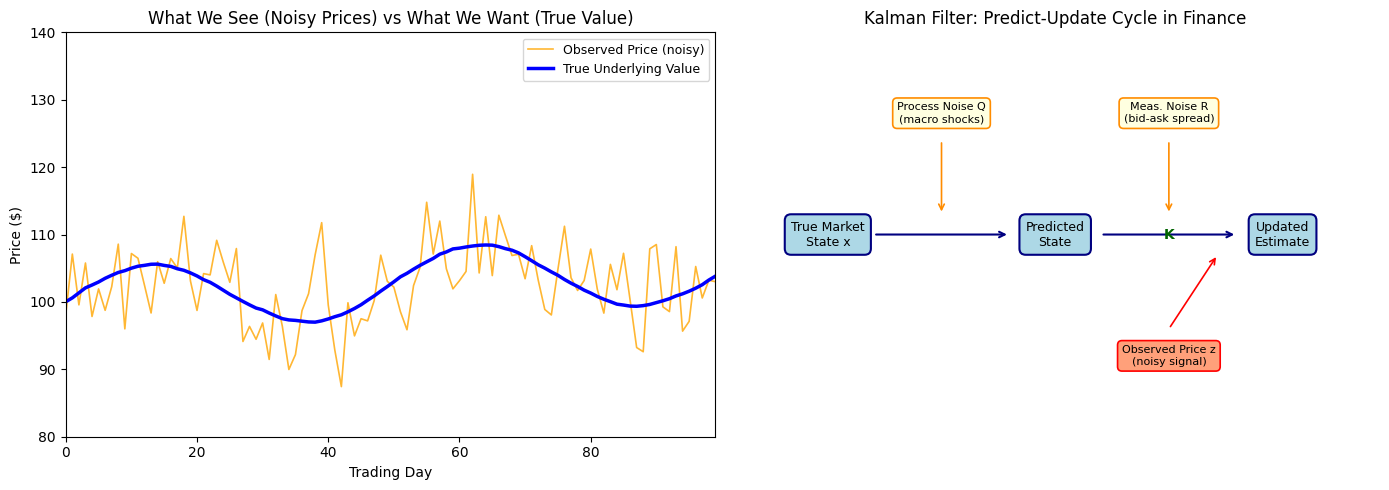

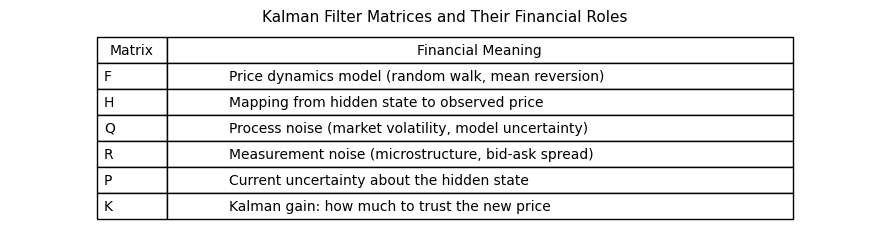

In [8]:
# Show noisy price vs true underlying value and Kalman flow diagram.
utils.plot_intro_signal_vs_noise()

## Cell 2: Linear Kalman Filter - Extracting Price Trend from Noise

- Purpose: Show how KalmanFilter tracks the latent price trend from noisy
  daily observations using a constant-velocity (trend + drift) state model.
- Larger R means we trust prices less and smooth more; larger Q lets the
  filter track rapid price changes.
- The ratio R/Q is the key tuning knob.

In [9]:
# Display interactive linear KF trend extraction with R and Q sliders.
utils.show_linear_kf_trend_interactive()

## Cell 3: Linear Kalman Filter - Kalman Gain and Uncertainty Convergence

- Purpose: Show how the state covariance P and Kalman gain K evolve over
  time, giving intuition about when the filter trusts new prices vs the model.
- P converges to a steady state independent of P0; K decreases as the filter
  learns; this mirrors how an investor becomes more confident over time.

In [10]:
# Display interactive covariance P and Kalman gain K convergence.
utils.show_kf_uncertainty_interactive()

## Cell 4: Extended Kalman Filter - Time-Varying Beta in Pairs Trading

- Purpose: Introduce the EKF for tracking a nonlinear, time-varying hedge
  ratio (beta) between two correlated stocks in a pairs trading strategy.
- EKF tracks beta in real time as the relationship evolves; cleaner spread
  means fewer false trading signals.
- State is log(beta); h(x) = exp(x)*stock_b is nonlinear.

In [ ]:
# Display interactive EKF pairs trading beta estimation.
utils.show_ekf_pairs_trading_interactive()

## Cell 5: Extended Kalman Filter - Linearization in Log-Return Space

- Purpose: Visually show how EKF linearizes the nonlinear log transformation
  used in log-return models and where the approximation breaks down.
- EKF error grows with uncertainty and curvature; far from x0 (crash
  scenarios) EKF can diverge; this motivates UKF for more volatile regimes.

In [ ]:
# Display interactive EKF linearization visualization.
utils.show_ekf_linearization_interactive()

## Cell 6: Unscented Kalman Filter - Stochastic Volatility Estimation

- Purpose: Show how UKF uses sigma points to estimate latent volatility from
  observed returns without computing Jacobians.
- UKF captures the asymmetry of log-volatility without Jacobians; 2n+1 = 3
  sigma points span the scalar state distribution.

In [ ]:
# Display interactive UKF stochastic volatility estimation.
utils.show_ukf_volatility_interactive()

## Cell 7: UKF vs EKF - Volatility Estimation Under Market Stress

- Purpose: Directly compare UKF and EKF on stochastic volatility estimation
  during a simulated market stress event (sudden volatility spike).
- EKF degrades faster than UKF under nonlinear stress regimes; UKF RMSE
  advantage grows with spike magnitude.

In [ ]:
# Display interactive UKF vs EKF comparison under market stress.
utils.show_ukf_vs_ekf_stress_interactive()

## Cell 8: Ensemble Kalman Filter - Portfolio Risk Scenario Analysis

- Purpose: Show EnsembleKalmanFilter as a Monte Carlo tool where each
  particle represents a possible portfolio price state.
- The ensemble spread is a natural measure of tail risk; unlike Gaussian
  approximations the ensemble can capture skewed distributions.

In [ ]:
# Display interactive EnKF portfolio risk scenario analysis.
utils.show_enkf_portfolio_interactive()

## Cell 9: All Four Filters - Financial State Estimation Comparison

- Purpose: Directly compare KF, EKF, UKF, and EnKF on the same financial
  state estimation problem and summarize when to use each filter.
- KF is optimal for linear models; EKF for mildly nonlinear; UKF for
  strongly nonlinear; EnKF for the full portfolio distribution.

In [ ]:
# Run and display all four filters side by side with RMSE comparison.
utils.plot_all_filters_financial_comparison()